# Test file for CIC-IDS2017 model creation and analysis

### 1. Data loading

In [11]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from datetime import datetime
from datetime import timedelta

pd.options.display.max_rows = 80

# import data from Data folder, csv files
#path = os.path.join(os.getcwd(), 'Data')
#files = os.listdir(path)

# read data from csv files and combine them into one dataframe and save it as a csv file
#data = pd.DataFrame()
#progress = 0
#for file in files:
#    if file.endswith('.csv'):
#        data = pd.concat([data, pd.read_csv(os.path.join(path, file))])
#        progress += 1
#        print(f'{progress} files have been combined')

#data.to_csv(os.path.join(path,'combine.csv'), index=False)

In [1]:
import pandas as pd
import os

# read data

df = pd.read_csv('/mnt/AI-DATA/alara/CiberIA_O1/Data/CIC-IDS2017.csv')

### 2. Data exploration

In [2]:
from IPython.display import display
display(df.head())

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.10.5-8.254.250.126-49188-80-6,8.254.250.126,80.0,192.168.10.5,49188.0,6.0,03/07/2017 08:55:58,4.0,2.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1,192.168.10.5-8.254.250.126-49188-80-6,8.254.250.126,80.0,192.168.10.5,49188.0,6.0,03/07/2017 08:55:58,1.0,2.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,192.168.10.5-8.254.250.126-49188-80-6,8.254.250.126,80.0,192.168.10.5,49188.0,6.0,03/07/2017 08:55:58,1.0,2.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
3,192.168.10.5-8.254.250.126-49188-80-6,8.254.250.126,80.0,192.168.10.5,49188.0,6.0,03/07/2017 08:55:58,1.0,2.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
4,192.168.10.14-8.253.185.121-49486-80-6,8.253.185.121,80.0,192.168.10.14,49486.0,6.0,03/07/2017 08:56:22,3.0,2.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


In [3]:
print('Cantidad de Filas y columnas:',df.shape)
print('Nombre columnas:',df.columns)

Cantidad de Filas y columnas: (2830743, 85)
Nombre columnas: Index(['Flow ID', 'Source IP', 'Source Port', 'Destination IP',
       'Destination Port', 'Protocol', 'Timestamp', 'Flow Duration',
       'Total Fwd Packets', 'Total Backward Packets',
       'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min 

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 85 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Flow ID                      object 
 1   Source IP                    object 
 2   Source Port                  float64
 3   Destination IP               object 
 4   Destination Port             float64
 5   Protocol                     float64
 6   Timestamp                    object 
 7   Flow Duration                float64
 8   Total Fwd Packets            float64
 9   Total Backward Packets       float64
 10  Total Length of Fwd Packets  float64
 11  Total Length of Bwd Packets  float64
 12  Fwd Packet Length Max        float64
 13  Fwd Packet Length Min        float64
 14  Fwd Packet Length Mean       float64
 15  Fwd Packet Length Std        float64
 16  Bwd Packet Length Max        float64
 17  Bwd Packet Length Min        float64
 18  Bwd Packet Length Mean       float64
 19  

In [5]:
# parse Label to string
df['Label'] = df['Label'].astype(str)

In [6]:
df.describe().transpose()

/home/alara/CiberIA_O1/env/lib/python3.11/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/alara/CiberIA_O1/env/lib/python3.11/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,25%,50%,75%,max
Source Port,2830743.0,4.112886e+04,2.229494e+04,0.0,32774.0,50944.0,58413.0,65535.0
Destination Port,2830743.0,8.071483e+03,1.828363e+04,0.0,53.0,80.0,443.0,65535.0
Protocol,2830743.0,9.880341e+00,5.261922e+00,0.0,6.0,6.0,17.0,17.0
Flow Duration,2830743.0,1.478566e+07,3.365374e+07,-13.0,155.0,31316.0,3204828.5,119999998.0
Total Fwd Packets,2830743.0,9.361160e+00,7.496728e+02,1.0,2.0,2.0,5.0,219759.0
...,...,...,...,...,...,...,...,...
Active Min,2830743.0,5.829582e+04,5.770923e+05,0.0,0.0,0.0,0.0,110000000.0
Idle Mean,2830743.0,8.316037e+06,2.363008e+07,0.0,0.0,0.0,0.0,120000000.0
Idle Std,2830743.0,5.038439e+05,4.602984e+06,0.0,0.0,0.0,0.0,76900000.0
Idle Max,2830743.0,8.695752e+06,2.436689e+07,0.0,0.0,0.0,0.0,120000000.0


### 3. Data cleaning

In [7]:
# Duplicate values
duplicates = df.duplicated()
print(f'There are {duplicates.sum()} duplicated rows in the dataset. Total shape: {df.shape}')


There are 203 duplicated rows in the dataset. Total shape: (2830743, 85)


In [8]:
df.drop_duplicates(inplace=True)
print(f'Duplicated rows have been removed. New shape: {df.shape}')

Duplicated rows have been removed. New shape: (2830540, 85)


In [9]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing)

Flow Bytes/s    1357
dtype: int64


In [12]:
# Checking for infinity values
numeric_cols = df.select_dtypes(include = np.number).columns
inf_count = np.isinf(df[numeric_cols]).sum()
print(inf_count[inf_count > 0])

Flow Bytes/s      1506
Flow Packets/s    2863
dtype: int64


In [13]:
# Replacing any infinite values (positive or negative) with NaN (not a number)
print(f'Initial missing values: {df.isna().sum().sum()}')

df.replace([np.inf, -np.inf], np.nan, inplace = True)

print(f'Missing values after processing infinite values: {df.isna().sum().sum()}')

missing = df.isna().sum()
print(missing.loc[missing > 0])

Initial missing values: 1357
Missing values after processing infinite values: 5726
Flow Bytes/s      2863
Flow Packets/s    2863
dtype: int64


In [14]:
# Calculating missing value percentage in the dataset
mis_per = (missing / len(df)) * 100
mis_table = pd.concat([missing, mis_per.round(2)], axis = 1)
mis_table = mis_table.rename(columns = {0 : 'Missing Values', 1 : 'Percentage of Total Values'})

print(mis_table.loc[mis_per > 0])

                Missing Values  Percentage of Total Values
Flow Bytes/s              2863                         0.1
Flow Packets/s            2863                         0.1


In [15]:
med_flow_bytes = df['Flow Bytes/s'].median()
med_flow_packets = df['Flow Packets/s'].median()

print('Median of Flow Bytes/s: ', med_flow_bytes)
print('Median of Flow Packets/s: ', med_flow_packets)

Median of Flow Bytes/s:  4587.249903
Median of Flow Packets/s:  109.3782757


In [16]:
# Filling missing values with median
df['Flow Bytes/s'].fillna(med_flow_bytes, inplace = True)
df['Flow Packets/s'].fillna(med_flow_packets, inplace = True)

print('Number of \'Flow Bytes/s\' missing values:', df['Flow Bytes/s'].isna().sum())
print('Number of \'Flow Packets/s\' missing values:', df['Flow Packets/s'].isna().sum())

Number of 'Flow Bytes/s' missing values: 0
Number of 'Flow Packets/s' missing values: 0


/tmp/ipykernel_3155207/4078083560.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Flow Bytes/s'].fillna(med_flow_bytes, inplace = True)
/tmp/ipykernel_3155207/4078083560.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpla

In [19]:
#save the cleaned data
df.to_csv('/mnt/AI-DATA/alara/CiberIA_O1/Data/CIC-IDS2017_clean.csv', index=False)

### 4. Data visualization


In [17]:
df['Label'].value_counts()

Label
BENIGN                         2272895
DoS Hulk                        231072
PortScan                        158930
DDoS                            128027
DoS GoldenEye                    10293
FTP-Patator                       7938
SSH-Patator                       5897
DoS slowloris                     5796
DoS Slowhttptest                  5499
Bot                               1966
Web Attack Â Brute Force         1507
Web Attack Â XSS                  652
Infiltration                        36
Web Attack Â Sql Injection         21
Heartbleed                          11
Name: count, dtype: int64

In [18]:
attack_map = {
    'BENIGN': 'BENIGN',
    'DDoS': 'DDoS',
    'DoS Hulk': 'DoS',
    'DoS GoldenEye': 'DoS',
    'DoS slowloris': 'DoS',
    'DoS Slowhttptest': 'DoS',
    'PortScan': 'Port Scan',
    'FTP-Patator': 'Brute Force',
    'SSH-Patator': 'Brute Force',
    'Bot': 'Bot',
    'Web Attack Â Brute Force': 'Web Attack',
    'Web Attack Â XSS': 'Web Attack',
    'Web Attack Â Sql Injection': 'Web Attack',
    'Infiltration': 'Infiltration',
    'Heartbleed': 'Heartbleed'
}

# Creating a new column 'Attack Type' in the DataFrame based on the attack_map dictionary
df['Attack Type'] = df['Label'].map(attack_map)
df['Attack Type'].value_counts()
df.drop('Label', axis = 1, inplace = True)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Attack Number'] = le.fit_transform(df['Attack Type'])

encoded_values = df['Attack Number'].unique()
for val in sorted(encoded_values):
    print(f"{val}: {le.inverse_transform([val])[0]}")

In [ ]:
corr = df.corr(numeric_only = True).round(2)
corr.style.background_gradient(cmap = 'coolwarm', axis = None).format(precision = 2)

fig, ax = plt.subplots(figsize = (24, 24))
sns.heatmap(corr, cmap = 'coolwarm', annot = False, linewidth = 0.5)
plt.title('Correlation Matrix', fontsize = 18)
plt.show()

In [ ]:
pos_corr_features = corr['Attack Number'][(corr['Attack Number'] > 0) & (corr['Attack Number'] < 1)].index.tolist()
# ordenador por valor absoluto
pos_corr_features.sort(key = lambda x: abs(corr.loc[x, 'Attack Number']), reverse = True)

print("Features with positive correlation with 'Attack Number':\n")
for i, feature in enumerate(pos_corr_features, start = 1):
    corr_value = corr.loc[feature, 'Attack Number']
    print('{:<3} {:<24} :{}'.format(f'{i}.', feature, corr_value))

print(f'Number of considerable important features: {len(pos_corr_features)}')

In [ ]:
# Identifying outliers
numeric_data = df.select_dtypes(include = ['float', 'int'])
q1 = numeric_data.quantile(0.25)
q3 = numeric_data.quantile(0.75)
iqr = q3 - q1
outlier = (numeric_data < (q1 - 1.5 * iqr)) | (numeric_data > (q3 + 1.5 * iqr))
outlier_count = outlier.sum()
outlier_percentage = round(outlier.mean() * 100, 2)
outlier_stats = pd.concat([outlier_count, outlier_percentage], axis = 1)
outlier_stats.columns = ['Outlier Count', 'Outlier Percentage']

print(outlier_stats)

In [ ]:
# Identifying outliers based on attack type
outlier_counts = {}
for i in numeric_data:
    for attack_type in df['Attack Type'].unique():
        attack_data = df[i][df['Attack Type'] == attack_type]
        q1, q3 = np.percentile(attack_data, [25, 75])
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        num_outliers = ((attack_data < lower_bound) | (attack_data > upper_bound)).sum()
        outlier_percent = num_outliers / len(attack_data) * 100
        outlier_counts[(i, attack_type)] = (num_outliers, outlier_percent)

for i in numeric_data:
  print(f'Feature: {i}')
  for attack_type in df['Attack Type'].unique():
    num_outliers, outlier_percent = outlier_counts[(i, attack_type)]
    print(f'- {attack_type}: {num_outliers} ({outlier_percent:.2f}%)')
  print()

In [ ]:
# Plotting the percentage of outliers that are higher than 20%
fig, ax = plt.subplots(figsize = (24, 10))
for i in numeric_data:
    for attack_type in df['Attack Type'].unique():
        num_outliers, outlier_percent = outlier_counts[(i, attack_type)]
        if outlier_percent > 20:
            ax.bar(f'{i} - {attack_type}', outlier_percent)

ax.set_xlabel('Feature-Attack Type')
ax.set_ylabel('Percentage of Outliers')
ax.set_title('Outlier Analysis')
ax.set_yticks(np.arange(0, 41, 10))
plt.xticks(rotation = 90)
plt.show()

In [ ]:
# Different 'Attack Type' in the main dataset excluding 'BENIGN'
attacks = df.loc[df['Attack Type'] != 'BENIGN']

plt.figure(figsize = (10, 6))
ax = sns.countplot(x = 'Attack Type', data = attacks, palette = 'pastel', order = attacks['Attack Type'].value_counts().index)
plt.title('Types of attacks')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.xticks(rotation = 90)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2, p.get_height() + 1000), ha = 'center')

plt.show()

In [ ]:
# Calculate attack type distribution
attack_counts = attacks['Attack Type'].value_counts()
threshold = 0.005
percentages = attack_counts / attack_counts.sum()
small_slices = percentages[percentages < threshold].index.tolist()

# Combine small categories into 'Other'
if small_slices:
    other_sum = attack_counts[small_slices].sum()
    attack_counts = attack_counts.drop(small_slices)
    attack_counts['Other'] = other_sum

# Plot settings
sns.set_palette('pastel')
plt.figure(figsize=(6,6))

# Improved labels with clearer formatting
explode = [0.05 if label == 'Other' else 0 for label in attack_counts.index]
plt.pie(
    attack_counts.values, 
    labels=attack_counts.index, 
    autopct='%1.1f%%', 
    textprops={'fontsize': 10},
    explode=explode,
    startangle=387
)

# Title and legend adjustments
plt.legend(attack_counts.index, loc='upper right', fontsize=10)
plt.tight_layout()
plt.savefig('attack_distribution.png',dpi=500)
plt.show()


In [ ]:
# Creating a boxplot for each attack type with the columns of sampled dataset
for attack_type in df['Attack Type'].unique():
    attack_data = df[df['Attack Type'] == attack_type]
    plt.figure(figsize=(20, 20))
    sns.boxplot(data = attack_data.drop(columns = ['Attack Type']), orient = 'h')
    plt.title(f'Boxplot of Features for Attack Type: {attack_type}')
    plt.xlabel('Feature Value')
    plt.show()

### 5. Data preprocessing

In [ ]:
# For improving performance and reduce memory-related errors
old_memory_usage = df.memory_usage().sum() / 1024 ** 2
print(f'Initial memory usage: {old_memory_usage:.2f} MB')
for col in df.columns:
    col_type = df[col].dtype
    if col_type != object:
        c_min = df[col].min()
        c_max = df[col].max()
        # Downcasting float64 to float32
        if str(col_type).find('float') >= 0 and c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
            df[col] = df[col].astype(np.float32)

        # Downcasting int64 to int32
        elif str(col_type).find('int') >= 0 and c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
            df[col] = df[col].astype(np.int32)

new_memory_usage = df.memory_usage().sum() / 1024 ** 2
print(f"Final memory usage: {new_memory_usage:.2f} MB")

# Calculating percentage reduction in memory usage
print(f'Reduced memory usage: {1 - (new_memory_usage / old_memory_usage):.2%}')

In [ ]:
# Dropping columns with only one unique value
num_unique = df.nunique()
one_variable = num_unique[num_unique == 1]
not_one_variable = num_unique[num_unique > 1].index

dropped_cols = one_variable.index
data = df[not_one_variable]

print('Dropped columns:')
dropped_cols

In [ ]:
data.info()

In [ ]:
# save only numerical data
attacks = data['Attack Type']
data = data.select_dtypes(include = ['float32', 'int32'])

#### PCA

In [ ]:
# Standardizing the dataset
from sklearn.preprocessing import StandardScaler

features = data

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

from sklearn.decomposition import IncrementalPCA

size = len(features.columns) // 2
ipca = IncrementalPCA(n_components = size, batch_size = 500)
for batch in np.array_split(scaled_features, len(features) // 500):
    ipca.partial_fit(batch)

print(f'information retained: {sum(ipca.explained_variance_ratio_):.2%}')

transformed_features = ipca.transform(scaled_features)
new_data_pca = pd.DataFrame(transformed_features, columns = [f'PC{i+1}' for i in range(size)])
new_data_pca['Attack Type'] = attacks.values

new_data_pca

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import f1_score

# --- SUPUESTOS ---
# Se asume que tienes dos variables:
# - 'data': un DataFrame con las features.
# - 'attacks': una Serie (o DataFrame) con la variable objetivo.

# Combinar las features y el target para facilitar el muestreo
df = data.copy()
df['Attack Type'] = attacks.values

# Muestrear 2000 filas para agilizar el cómputo (opcional)
df_sample = df.sample(n=70000, random_state=42)

# Separar variables predictoras (X) y variable objetivo (y)
X = df_sample.drop('Attack Type', axis=1)
y = df_sample['Attack Type']

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Diccionario para almacenar los resultados
results = {}

# Número total de features
num_features = X_train.shape[1]

# Iterar sobre distintos valores de k (número de features seleccionadas) de 5 en 5
for k in range(5, num_features + 1, 1):
    print(f"\nNúmero de features seleccionadas: {k}")
    
    # Realizar la selección de features sobre el conjunto de entrenamiento
    selector = SelectKBest(score_func=f_classif, k=k)
    selector.fit(X_train, y_train)
    
    # Transformar tanto entrenamiento como prueba usando el selector ajustado
    X_train_sel = selector.transform(X_train)
    X_test_sel = selector.transform(X_test)
    
    # Definir los clasificadores base:
    estimators = [
        ('svm', SVC(probability=True, random_state=42)),
        ('mlp', MLPClassifier(max_iter=500, random_state=42))
    ]
    
    # Definir el clasificador meta (stacking) utilizando regresión logística
    final_estimator = LogisticRegression(max_iter=1000, random_state=42)
    
    stacking_clf = StackingClassifier(estimators=estimators,
                                      final_estimator=final_estimator,
                                      cv=5,            # validación cruzada interna para el stacking
                                      passthrough=False)
    
    # Entrenar el meta clasificador con las features seleccionadas
    stacking_clf.fit(X_train_sel, y_train)
    
    # Realizar predicciones en el conjunto de prueba
    y_pred = stacking_clf.predict(X_test_sel)
    
    # Calcular las métricas: Accuracy y F1 Score ponderado
    accuracy = stacking_clf.score(X_test_sel, y_test)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    print(f"Accuracy: {accuracy:.6f}")
    print(f"F1 Score: {f1:.6f}")
    
    # Guardar los resultados en el diccionario
    results[k] = [accuracy, f1]

# Convertir el diccionario de resultados en un DataFrame para visualizar mejor
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy', 'F1 Score'])
print("\nResumen de resultados:")
print(results_df)

# Graficar la evolución de las métricas según el número de features seleccionadas
fig, ax = plt.subplots(figsize=(12, 6))
results_df.plot(ax=ax, marker='o')
plt.title('Métricas de rendimiento vs Número de Features (Meta clasificador)')
plt.xlabel('Número de Features Seleccionadas')
plt.ylabel('Score')
plt.grid(True)
plt.show()


In [ ]:
# select k best features
from sklearn.feature_selection import SelectKBest, f_classif

features = data
target = attacks

k = 20
selector = SelectKBest(f_classif, k = k)
selector.fit(features, target)

selected_features = features.columns[selector.get_support()]
selected_features

print(f'Selected Features: {selected_features}')

# save selected features
new_data_k_20 = data[selected_features]
new_data_k_20['Attack Type'] = attacks.values

k = 40
selector = SelectKBest(f_classif, k = k)
selector.fit(features, target)

selected_features = features.columns[selector.get_support()]
selected_features

print(f'Selected Features: {selected_features}')

# save selected features
new_data_k_40 = data[selected_features]
new_data_k_40['Attack Type'] = attacks.values

In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Assuming `new_data_k` is your dataset with selected features and the target
# `selected_features` contains the names of your selected features
# `attacks` is your target variable (e.g., 'Attack Type')

# Calculate Information Gain for each selected feature
info_gain_values = mutual_info_classif(new_data_k[selected_features], new_data_k['Attack Type'], random_state=0)

# Create a DataFrame to display feature names and their Information Gain
info_gain_df = pd.DataFrame({
    'Feature': selected_features,
    'Information Gain': info_gain_values
}).sort_values(by='Information Gain', ascending=False)

# Display the Information Gain values
print("\nInformation Gain for Selected Features:")
print(info_gain_df)

### 5. Model training

##### Binary classification

In [ ]:
# For cross validation
from sklearn.model_selection import cross_val_score

In [ ]:
# Creating a balanced dataset for Binary Classification
normal_traffic = new_data_pca.loc[new_data_pca['Attack Type'] == 'BENIGN']
intrusions = new_data_pca.loc[new_data_pca['Attack Type'] != 'BENIGN']

normal_traffic = normal_traffic.sample(n = len(intrusions), replace = False)

ids_data = pd.concat([intrusions, normal_traffic])
ids_data['Attack Type'] = np.where((ids_data['Attack Type'] == 'BENIGN'), 0, 1)
bc_data = ids_data.sample(n = 15000)

print(bc_data['Attack Type'].value_counts())

In [ ]:
# Splitting the data into features (X) and target (y)
from sklearn.model_selection import train_test_split

X_bc = bc_data.drop('Attack Type', axis = 1)
y_bc = bc_data['Attack Type']

X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(X_bc, y_bc, test_size = 0.25, random_state = 0)

#### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

lr1 = LogisticRegression(max_iter = 10000, C = 0.1, random_state = 0, solver = 'saga')
lr1.fit(X_train_bc, y_train_bc)

cv_lr1 = cross_val_score(lr1, X_train_bc, y_train_bc, cv = 5)
print('Logistic regression Model 1')
print(f'\nCross-validation scores:', ', '.join(map(str, cv_lr1)))
print(f'\nMean cross-validation score: {cv_lr1.mean():.2f}')

from sklearn.metrics import classification_report

y_pred_lr1 = lr1.predict(X_test_bc)
print('Logistic regression Model 1')
print('\nClassification Report:')
print(classification_report(y_test_bc, y_pred_lr1, digits=4))

from sklearn.metrics import confusion_matrix

cm_lr1 = confusion_matrix(y_test_bc, y_pred_lr1)
print('Logistic regression Model 1')
print('\nConfusion Matrix:')

plt.figure(figsize = (8, 6))
sns.heatmap(cm_lr1, annot = True, fmt = 'd', cmap = 'cividis', xticklabels = ['Normal', 'Intrusion'], yticklabels = ['Normal', 'Intrusion'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

#### SVM

In [ ]:
from sklearn.svm import SVC

svm1 = SVC(kernel = 'rbf', C = 1, random_state = 0, probability = True)
svm1.fit(X_train_bc, y_train_bc)

cv_svm1 = cross_val_score(svm1, X_train_bc, y_train_bc, cv = 5)
print('Support Vector Machine Model 1')
print(f'\nCross-validation scores:', ', '.join(map(str, cv_svm1)))
print(f'\nMean cross-validation score: {cv_svm1.mean():.2f}')

# classification report
y_pred_svm1 = svm1.predict(X_test_bc)
print('Support Vector Machine Model 1')
print('\nClassification Report:')
print(classification_report(y_test_bc, y_pred_svm1, digits=4))

# confusion matrix
cm_svm1 = confusion_matrix(y_test_bc, y_pred_svm1)
print('Support Vector Machine Model 1')
print('\nConfusion Matrix:')
plt.figure(figsize = (8, 6))
sns.heatmap(cm_svm1, annot = True, fmt = 'd', cmap = 'cividis', xticklabels = ['Normal', 'Intrusion'], yticklabels = ['Normal', 'Intrusion'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

#### Neural Network

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# one hot encoding witout using to_categorical
y_test_cat = pd.get_dummies(y_test_bc)
y_train_cat = pd.get_dummies(y_train_bc)

# Define the model
model = Sequential()
model.add(Dense(128, input_dim=X_train_bc.shape[1], activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(y_train_cat.shape[1], activation='softmax'))

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
history = model.fit(X_train_bc, y_train_cat, epochs=50, batch_size=256, validation_data=(X_test_bc, y_test_cat))

# Evaluate the model
loss, accuracy = model.evaluate(X_test_bc, y_test_cat)
print(f'Test Accuracy: {accuracy:.2f}')

# plot accuracy and loss across epochs
plt.figure(figsize=(8, 8))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
# matrix confusion
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test_bc)
y_pred = np.argmax(y_pred, axis=1)
y_test = np.argmax(y_test_cat.values, axis=1)

print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='cividis', xticklabels=['Normal', 'Intrusion'], yticklabels=['Normal', 'Intrusion'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

##### Multi-class classification

In [ ]:
new_data_pca['Attack Type'].value_counts()

In [ ]:
from imblearn.over_sampling import SMOTE

class_counts = new_data_pca['Attack Type'].value_counts()
selected_classes = class_counts[class_counts > 1950]
class_names = selected_classes.index
selected = new_data_pca[new_data_pca['Attack Type'].isin(class_names)]

dfs = []
for name in class_names:
  df = selected[selected['Attack Type'] == name]
  if len(df) > 2500:
    df = df.sample(n = 10000, random_state = 0)

  dfs.append(df)

df = pd.concat(dfs, ignore_index = True)

X = df.drop('Attack Type', axis=1)
y = df['Attack Type']

smote = SMOTE(sampling_strategy='auto', random_state=0)
X_upsampled, y_upsampled = smote.fit_resample(X, y)

blnc_data = pd.DataFrame(X_upsampled)
blnc_data['Attack Type'] = y_upsampled
blnc_data = blnc_data.sample(frac=1)

features = blnc_data.drop('Attack Type', axis = 1)
labels = blnc_data['Attack Type']

X_train_S_PCA, X_test_S_PCA, y_train_S_PCA, y_test_S_PCA = train_test_split(features, labels, test_size = 0.3, random_state = 0)

#######################################################################

class_counts = new_data_k_20['Attack Type'].value_counts()
selected_classes = class_counts[class_counts > 1950]
class_names = selected_classes.index
selected = new_data_k_20[new_data_k_20['Attack Type'].isin(class_names)]

dfs = []
for name in class_names:
  df = selected[selected['Attack Type'] == name]
  if len(df) > 2500:
    df = df.sample(n = 10000, random_state = 0)

  dfs.append(df)

df = pd.concat(dfs, ignore_index = True)

X = df.drop('Attack Type', axis=1)
y = df['Attack Type']

smote = SMOTE(sampling_strategy='auto', random_state=0)
X_upsampled, y_upsampled = smote.fit_resample(X, y)

blnc_data = pd.DataFrame(X_upsampled)
blnc_data['Attack Type'] = y_upsampled
blnc_data = blnc_data.sample(frac=1)

features = blnc_data.drop('Attack Type', axis = 1)
labels = blnc_data['Attack Type']

X_train_S_20, X_test_S_20, y_train_S_20, y_test_S_20 = train_test_split(features, labels, test_size = 0.3, random_state = 0)

#######################################################################

class_counts = new_data_k_40['Attack Type'].value_counts()
selected_classes = class_counts[class_counts > 1950]
class_names = selected_classes.index
selected = new_data_k_40[new_data_k_40['Attack Type'].isin(class_names)]

dfs = []
for name in class_names:
  df = selected[selected['Attack Type'] == name]
  if len(df) > 2500:
    df = df.sample(n = 10000, random_state = 0)

  dfs.append(df)

df = pd.concat(dfs, ignore_index = True)

X = df.drop('Attack Type', axis=1)
y = df['Attack Type']

smote = SMOTE(sampling_strategy='auto', random_state=0)
X_upsampled, y_upsampled = smote.fit_resample(X, y)

blnc_data = pd.DataFrame(X_upsampled)
blnc_data['Attack Type'] = y_upsampled
blnc_data = blnc_data.sample(frac=1)

features = blnc_data.drop('Attack Type', axis = 1)
labels = blnc_data['Attack Type']

X_train_S_40, X_test_S_40, y_train_S_40, y_test_S_40 = train_test_split(features, labels, test_size = 0.3, random_state = 0)

In [ ]:
# no_smote
features = new_data_pca.drop('Attack Type', axis = 1)
labels = new_data_pca['Attack Type']

# sample of 70000
features = features.sample(n = 70000, random_state = 0)
labels = labels.sample(n = 70000, random_state = 0)

X_train_N_PCA, X_test_N_PCA, y_train_N_PCA, y_test_N_PCA = train_test_split(features, labels, test_size = 0.3, random_state = 0)

################################################################

# no_smote
features = new_data_k_20.drop('Attack Type', axis = 1)
labels = new_data_k_20['Attack Type']

# sample of 70000
features = features.sample(n = 70000, random_state = 0)
labels = labels.sample(n = 70000, random_state = 0)

X_train_N_20, X_test_N_20, y_train_N_20, y_test_N_20 = train_test_split(features, labels, test_size = 0.3, random_state = 0)

################################################################

# no_smote
features = new_data_k_40.drop('Attack Type', axis = 1)
labels = new_data_k_40['Attack Type']

# sample of 70000
features = features.sample(n = 70000, random_state = 0)
labels = labels.sample(n = 70000, random_state = 0)

X_train_N_40, X_test_N_40, y_train_N_40, y_test_N_40 = train_test_split(features, labels, test_size = 0.3, random_state = 0)

#### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from time import time

# iterate using data: train_S_PCA, train_S_20, train_S_40, train_N_PCA, train_N_20, train_N_40

for i in range(6):
    if i == 0:
        X_train = X_train_S_PCA
        y_train = y_train_S_PCA
        X_test = X_test_S_PCA
        y_test = y_test_S_PCA
        model_name = 'Support PCA'
    elif i == 1:
        X_train = X_train_S_20
        y_train = y_train_S_20
        X_test = X_test_S_20
        y_test = y_test_S_20
        model_name = 'Support 20'
    elif i == 2:
        X_train = X_train_S_40
        y_train = y_train_S_40
        X_test = X_test_S_40
        y_test = y_test_S_40
        model_name = 'Support 40'
    elif i == 3:
        X_train = X_train_N_PCA
        y_train = y_train_N_PCA
        X_test = X_test_N_PCA
        y_test = y_test_N_PCA
        model_name = 'No Support PCA'
    elif i == 4:
        X_train = X_train_N_20
        y_train = y_train_N_20
        X_test = X_test_N_20
        y_test = y_test_N_20
        model_name = 'No Support 20'
    else:
        X_train = X_train_N_40
        y_train = y_train_N_40
        X_test = X_test_N_40
        y_test = y_test_N_40
        model_name = 'No Support 40'

    rf = RandomForestClassifier(n_estimators = 10, max_depth = 6, max_features = None, random_state = 0)
    rf.fit(X_train, y_train)

    start_time = time()
    cv_rf = cross_val_score(rf, X_train, y_train, cv = 5)
    print(f'{model_name} - Random Forest Model')
    print(f'\nCross-validation scores:', ', '.join(map(str, cv_rf)))
    print(f'\nMean cross-validation score: {cv_rf.mean():.2f}')

    print(f'\nExecution time: {time() - start_time:.2f} seconds')

    # classification report
    y_pred_rf = rf.predict(X_test)
    print(f'{model_name} - Random Forest Model')
    print('\nClassification Report:')
    print(classification_report(y_test, y_pred_rf, digits=4))

    # confusion matrix
    cm_rf1 = confusion_matrix(y_test, y_pred_rf)
    print('Random Forest Model 1')
    print('\nConfusion Matrix:')
    plt.figure(figsize = (8, 6))
    sns.heatmap(cm_rf1, annot = True, fmt = 'd', cmap = 'cividis', xticklabels = class_names, yticklabels = class_names)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()

#### LGBM

In [ ]:
import lightgbm as lgb

# Parameters for LightGBM
params = {
    'min_gain_to_split': 0.0,  # Lowering the threshold for splits
    'min_child_samples': 10,   # Preventing overfitting by controlling sample count per leaf
    'min_data_in_leaf': 20,    # Ensures enough data per leaf
    'num_leaves': 31,
    'max_depth': 10,
    'random_state': 0,
    'verbose': -1
}

# Create model for multiclass classification
lgb_clf = lgb.LGBMClassifier(**params)

# Train the models
lgb_clf.fit(X_train, y_train)

start_time = time()
cv_lgb = cross_val_score(lgb_clf, X_train, y_train, cv = 5)
print('LightGBM Model')
print(f'\nCross-validation scores:', ', '.join(map(str, cv_lgb)))
print(f'\nMean cross-validation score: {cv_lgb.mean():.2f}')
print(f'\nExecution time: {time() - start_time:.2f} seconds')

# classification report
y_pred_lgb = lgb_clf.predict(X_test)
print('LightGBM Model')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_lgb))

# confusion matrix
cm_lgb = confusion_matrix(y_test, y_pred_lgb)
print('LightGBM Model')
print('\nConfusion Matrix:')
plt.figure(figsize = (8, 6))
sns.heatmap(cm_lgb, annot = True, fmt = 'd', cmap = 'cividis', xticklabels = class_names, yticklabels = class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

#### K Nearest Neighbours

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn1 = KNeighborsClassifier(n_neighbors = 16)
knn1.fit(X_train, y_train)

cv_knn1 = cross_val_score(knn1, X_train, y_train, cv = 5)
print('K Nearest Neighbors Model 1')
print(f'\nCross-validation scores:', ', '.join(map(str, cv_knn1)))
print(f'\nMean cross-validation score: {cv_knn1.mean():.2f}')

# classification report
y_pred_knn1 = knn1.predict(X_test)
print('K Nearest Neighbors Model 1')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_knn1))

# confusion matrix
cm_knn1 = confusion_matrix(y_test, y_pred_knn1)
print('K Nearest Neighbors Model 1')
print('\nConfusion Matrix:')
plt.figure(figsize = (8, 6))
sns.heatmap(cm_knn1, annot = True, fmt = 'd', cmap = 'cividis', xticklabels = class_names, yticklabels = class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

#### Base Neural Network

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from time import time


# one hot encoding witout using to_categorical
y_test_cat = pd.get_dummies(y_test)
y_train_cat = pd.get_dummies(y_train)

# Define the model
model = Sequential()
model.add(Dense(128, input_dim=X_train.shape[1], activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(y_train_cat.shape[1], activation='softmax'))

time_start = time()
# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train_cat, epochs=20, batch_size=128, validation_data=(X_test, y_test_cat))

time_end = time()
print(f'Training time: {time_end - time_start:.2f} seconds')
# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test_cat)
print(f'Test Accuracy: {accuracy:.2f}')

# plot accuracy and loss across epochs
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# show classification report

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
y_test_new = np.argmax(y_test_cat.values, axis=1)

print(classification_report(y_test_new, y_pred))

# matrix confusion

cm = confusion_matrix(y_test_new, y_pred)

plt.figure(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='cividis', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

#### Ensemble method

In [ ]:
import lightgbm as lgb
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

params = {
    'min_gain_to_split': 0.0,  # Lowering the threshold for splits
    'min_child_samples': 10,   # Preventing overfitting by controlling sample count per leaf
    'min_data_in_leaf': 20,    # Ensures enough data per leaf
    'num_leaves': 31,
    'max_depth': 10,
    'random_state': 0,
    'verbose': -1
}

# Create a LightGBM classifier
lgb_clf = lgb.LGBMClassifier(**params)

# Build a stacking classifier with the previously defined RF model (rf1) and LightGBM
stacked_clf = StackingClassifier(
    estimators=[('rf', rf1), ('lgbm', lgb_clf)],
    final_estimator=LogisticRegression(max_iter=10000, random_state=0),
    cv=5
)

from time import time
start_time = time()
# Train the stacked model
stacked_clf.fit(X_train, y_train)
print(f'\nExecution time: {time() - start_time:.2f} seconds')

# Evaluate via cross-validation
cv_scores = cross_val_score(stacked_clf, X_train, y_train, cv=5)
print('Stacked Model CV Scores:', cv_scores)
print('Mean CV Score:', cv_scores.mean())

# classification report
y_pred_stacked = stacked_clf.predict(X_test)
print('\nClassification Report:')
print(classification_report(y_test, y_pred_stacked))

# confusion matrix
cm_stacked = confusion_matrix(y_test, y_pred_stacked)
print('\nConfusion Matrix:')
plt.figure(figsize=(8, 6))
sns.heatmap(cm_stacked, annot=True, fmt='d', cmap='cividis', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


#### Hybrid approach

In [ ]:
# Splitting data for binary classification (Layer 1)
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size = 0.3, random_state = 0)

# convert BENIGN to 0 and other attacks to 1
y_train_bc = np.where(y_train == 'BENIGN', 0, 1)
y_test_bc = np.where(y_test == 'BENIGN', 0, 1)

# One-hot encoding for the target labels
y_train_cat = pd.get_dummies(y_train_bc)
y_test_cat = pd.get_dummies(y_test_bc)

# Define the neural network for binary classification
model = Sequential()
model.add(Dense(128, input_dim=X_train.shape[1], activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(y_train_cat.shape[1], activation='softmax'))

from time import time
start_time = time()

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train_cat, epochs=5, batch_size=128, validation_data=(X_test, y_test_cat))

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test_cat)
print(f'Binary Classification Test Accuracy: {accuracy:.2f}')

# Confusion matrix for binary classification
y_pred_bc = np.argmax(model.predict(X_test), axis=1)
cm_bc = confusion_matrix(np.argmax(y_test_cat.values, axis=1), y_pred_bc)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_bc, annot=True, fmt='d', cmap='cividis', xticklabels=['Benign', 'Attack'], yticklabels=['Benign', 'Attack'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - Binary Classification')
plt.show()

# Filter data for second layer (attack samples only)
X_train_mc = X_train[np.argmax(y_train_cat.values, axis=1) == 1]
X_test_mc = X_test[np.argmax(y_test_cat.values, axis=1) == 1]
y_train_mc = y_train[np.argmax(y_train_cat.values, axis=1) == 1]
y_test_mc = y_test[np.argmax(y_test_cat.values, axis=1) == 1]

# Parameters for LightGBM
params = {
    'min_gain_to_split': 0.0,  # Lowering the threshold for splits
    'min_child_samples': 10,   # Preventing overfitting by controlling sample count per leaf
    'min_data_in_leaf': 20,    # Ensures enough data per leaf
    'num_leaves': 31,
    'max_depth': 10,
    'random_state': 0,
    'verbose': -1
}

# Create models for multiclass classification
rf1 = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
lgb_clf = lgb.LGBMClassifier(**params)

# Build stacking classifier
stacked_clf = StackingClassifier(
    estimators=[('rf', rf1), ('lgb', lgb_clf)],
    final_estimator=LogisticRegression(max_iter=10000, random_state=42),
    cv=5
)

# Train the stacked model
stacked_clf.fit(X_train_mc, y_train_mc)
print(f'\nExecution time: {time() - start_time:.2f} seconds')
# Evaluate via cross-validation
cv_scores = cross_val_score(stacked_clf, X_train_mc, y_train_mc, cv=5)
print('Stacked Model Cross-Validation Scores:', cv_scores)
print('Mean CV Score:', cv_scores.mean())

# Predictions and classification report
y_pred_mc = stacked_clf.predict(X_test_mc)
print('\nClassification Report - Multiclass Classification:')
print(classification_report(y_test_mc, y_pred_mc))

# Confusion matrix for multiclass classification
cm_mc = confusion_matrix(y_test_mc, y_pred_mc)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_mc, annot=True, fmt='d', cmap='cividis', xticklabels=np.unique(y_test_mc), yticklabels=np.unique(y_test_mc))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - Multiclass Classification')
plt.show()


#### RONI

In [ ]:
import numpy as np
import pandas as pd
import warnings
from time import time
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.cluster import KMeans

# Suppress the "feature names mismatch" warning
warnings.filterwarnings(
    "ignore",
    message="X has feature names, but LogisticRegression was fitted without feature names"
)

##############################################################################
# 1. Create (or load) a small dataset
##############################################################################

# Convert to DataFrame / Series for convenience
features = pd.DataFrame(features)
labels = pd.Series(labels)

# We sample 2% of the data to keep things small in this demo:
features_sample = features.sample(frac=0.01, random_state=0)
labels_sample = labels.loc[features_sample.index]

##############################################################################
# 2. Introduce 10 malicious ("bad") samples
##############################################################################
# In a real attack, an adversary might craft these more subtly. 
# Here, we simply:
# - Create 10 samples of all zeros (feature vectors).
# - Assign them a label "BENIGN" (which may or may not be correct for your domain).
num_bad = 10
X_bad = np.zeros((num_bad, features_sample.shape[1]))
# Let's label them all "BENIGN"
y_bad = ['BENIGN'] * num_bad

# Convert to DataFrame/Series so we can easily append
X_bad_df = pd.DataFrame(X_bad, columns=features_sample.columns)
y_bad_sr = pd.Series(y_bad)

# Append bad samples to the "features_sample" and "labels_sample"
features_with_bad = pd.concat([features_sample, X_bad_df], ignore_index=True)
labels_with_bad = pd.concat([labels_sample, y_bad_sr], ignore_index=True)

##############################################################################
# 3. Split into train / test
##############################################################################
X_train, X_test, y_train, y_test = train_test_split(
    features_with_bad,
    labels_with_bad,
    test_size=0.2,
    random_state=42
)

# Further split training into (train_main / validation)
X_train_main, X_val, y_train_main, y_val = train_test_split(
    X_train, 
    y_train, 
    test_size=0.2, 
    random_state=42
)

print(f"Train main set size: {len(X_train_main)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}\n")

##############################################################################
# 4. Train a baseline model (SVC in this example)
##############################################################################
start_time = time()

baseline_model = LogisticRegression(solver='liblinear', random_state=42, max_iter=10000)
baseline_model.fit(X_train_main, y_train_main)

baseline_acc = accuracy_score(y_val, baseline_model.predict(X_val))
print(f"Baseline validation accuracy: {baseline_acc:.3f}")

##############################################################################
# 5. Naive RONI detection: remove each sample, re-train, check validation
##############################################################################
negatively_influential_indices = []

# We'll track the indices of the malicious samples in X_train_main.
# Because we appended malicious samples at the end of 'features_sample',
# we know their original indices in the concatenated DataFrame start at:
original_len = len(features_sample)  # number of rows *before* adding 10 bad

train_indices = X_train_main.index  # these are the (original) row indices
bad_indices_in_train = []
for local_i, idx in enumerate(train_indices):
    if idx >= original_len:
        # idx >= original_len => It's one of the appended "bad" samples
        bad_indices_in_train.append(local_i)

# Now we do the naive RONI procedure
# We'll use LogisticRegression for speed in the RONI loop
for i in range(len(X_train_main)):
    # Remove the i-th sample from the training set
    X_minus_one = np.delete(X_train_main.to_numpy(), i, axis=0)
    y_minus_one = np.delete(y_train_main.to_numpy(), i)

    # Retrain quickly on the remaining data
    temp_model = LogisticRegression(solver='liblinear', random_state=42, max_iter=10000)
    temp_model.fit(X_minus_one, y_minus_one)

    # Check validation accuracy
    temp_acc = accuracy_score(y_val, temp_model.predict(X_val))

    # If removing this sample improves validation accuracy by > 5%,
    # we consider it negatively influential. Adjust threshold as you wish.
    if temp_acc > 1.05* baseline_acc:
        negatively_influential_indices.append(i)

print(f"Number of negatively influential samples (RONI): {len(negatively_influential_indices)}")

##############################################################################
# 6. Compute RONI detection statistics
##############################################################################
detected_bad_samples_roni = set(bad_indices_in_train).intersection(negatively_influential_indices)
num_detected_bad_roni = len(detected_bad_samples_roni)

# Detection accuracy = fraction of malicious samples that were caught
detection_accuracy_roni = (
    num_detected_bad_roni / len(bad_indices_in_train) 
    if bad_indices_in_train 
    else 0.0
)

# Number of errors (false positives) = total flagged - truly malicious among them
false_positives_roni = len(negatively_influential_indices) - num_detected_bad_roni

print("=== RONI Results ===")
print(f"Malicious samples actually in train_main: {bad_indices_in_train}")
print(f"Malicious samples detected by RONI: {detected_bad_samples_roni}")
print(f"RONI detection accuracy: {detection_accuracy_roni:.3f}")
print(f"RONI false positives (benign flagged as bad): {false_positives_roni}\n")
print(f"RONI Execution time: {time() - start_time:.2f} seconds\n")

##############################################################################
# 7. Retrain after RONI removal
##############################################################################
X_train_cleaned_roni = np.delete(X_train_main.to_numpy(), negatively_influential_indices, axis=0)
y_train_cleaned_roni = np.delete(y_train_main.to_numpy(), negatively_influential_indices)

final_model_roni = LogisticRegression(solver='liblinear', random_state=42, max_iter=10000)
final_model_roni.fit(X_train_cleaned_roni, y_train_cleaned_roni)

final_val_acc_roni = accuracy_score(y_val, final_model_roni.predict(X_val))
final_test_acc_roni = accuracy_score(y_test, final_model_roni.predict(X_test))

print("=== Performance after RONI ===")
print(f"Final validation accuracy after RONI: {final_val_acc_roni:.3f}")
print(f"Test accuracy after RONI: {final_test_acc_roni:.3f}")

##############################################################################
# 8. Clustering-based Detection (K-Means)
##############################################################################
# We'll use a simple approach:
#   1) Fit K-Means on the training data.
#   2) For each sample, compute distance to its assigned cluster centroid.
#   3) Label "outliers" as those with distance above (mean + 2 * std) 
#      in their assigned cluster. 
# In practice, you might choose # of clusters differently or use DBSCAN, etc.
start_time = time()
kmeans = KMeans(n_clusters=2, random_state=42)
train_array = X_train_main.to_numpy()

# Fit K-Means
kmeans.fit(train_array)

# For each sample, find its assigned cluster centroid
labels_km = kmeans.labels_             # cluster assignment
centers = kmeans.cluster_centers_      # shape: (n_clusters, n_features)

# Compute distances to the assigned centroid
distances = np.zeros(len(train_array))
for i, c_label in enumerate(labels_km):
    centroid = centers[c_label]
    dist = np.linalg.norm(train_array[i] - centroid)
    distances[i] = dist

# We'll define an outlier threshold per cluster: mean + 2*std of distances
outlier_thresholds = {}
for cluster_id in range(2):
    cluster_dists = distances[labels_km == cluster_id]
    mu = cluster_dists.mean()
    sigma = cluster_dists.std()
    outlier_thresholds[cluster_id] = mu + 2 * sigma

# Flag samples whose distance > threshold for their cluster
clustering_influential_indices = []
for i, c_label in enumerate(labels_km):
    if distances[i] > outlier_thresholds[c_label]:
        clustering_influential_indices.append(i)

print(f"\nNumber of negatively influential samples (Clustering): "
      f"{len(clustering_influential_indices)}")

##############################################################################
# 9. Compute Clustering detection statistics
##############################################################################
detected_bad_samples_cluster = (
    set(bad_indices_in_train).intersection(clustering_influential_indices)
)
num_detected_bad_cluster = len(detected_bad_samples_cluster)

detection_accuracy_cluster = (
    num_detected_bad_cluster / len(bad_indices_in_train) 
    if bad_indices_in_train 
    else 0.0
)

false_positives_cluster = len(clustering_influential_indices) - num_detected_bad_cluster

print("=== Clustering Results ===")
print(f"Malicious samples actually in train_main: {bad_indices_in_train}")
print(f"Malicious samples detected by Clustering: {detected_bad_samples_cluster}")
print(f"Clustering detection accuracy: {detection_accuracy_cluster:.3f}")
print(f"Clustering false positives: {false_positives_cluster}")
print(f"Clustering Execution time: {time() - start_time:.2f} seconds\n")

##############################################################################
# 10. Retrain after Clustering-based removal (optional)
##############################################################################
X_train_cleaned_cluster = np.delete(train_array, clustering_influential_indices, axis=0)
y_train_cleaned_cluster = np.delete(y_train_main.to_numpy(), clustering_influential_indices)

final_model_cluster = SVC(kernel='rbf', C=1, random_state=42, probability=True)
final_model_cluster.fit(X_train_cleaned_cluster, y_train_cleaned_cluster)

final_val_acc_cluster = accuracy_score(y_val, final_model_cluster.predict(X_val))
final_test_acc_cluster = accuracy_score(y_test, final_model_cluster.predict(X_test))

print("\n=== Performance after Clustering-based Removal ===")
print(f"Final validation accuracy after Clustering: {final_val_acc_cluster:.3f}")
print(f"Test accuracy after Clustering: {final_test_acc_cluster:.3f}")

print(f"\nExecution time: {time() - start_time:.2f} seconds")


In [ ]:
import numpy as np
import pandas as pd
import warnings
from time import time
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

##############################################################################
# 1. Convert your (already loaded) data into DataFrame / Series
##############################################################################
# (Assuming `features` and `labels` are already loaded in your environment.)

features = pd.DataFrame(features)
labels = pd.Series(labels)

# Sample 2% of your dataset, as in your snippet
features_sample = features.sample(frac=0.01, random_state=0)
labels_sample = labels.loc[features_sample.index]

##############################################################################
# 2. Inject 10 Malicious ("Bad") Samples
##############################################################################
num_bad = 10
X_bad = np.zeros((num_bad, features_sample.shape[1]))
y_bad = ['BENIGN'] * num_bad

X_bad_df = pd.DataFrame(X_bad, columns=features_sample.columns)
y_bad_sr = pd.Series(y_bad)

features_with_bad = pd.concat([features_sample, X_bad_df], ignore_index=True)
labels_with_bad = pd.concat([labels_sample, y_bad_sr], ignore_index=True)

##############################################################################
# 3. Split into Train / Test, then Train / Validation
##############################################################################
X_train, X_test, y_train, y_test = train_test_split(
    features_with_bad, 
    labels_with_bad, 
    test_size=0.2, 
    random_state=42
)

X_train_main, X_val, y_train_main, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)

print(f"Train main set size: {len(X_train_main)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}\n")

start_time = time()

##############################################################################
# 4. Baseline Model (SVC)
##############################################################################
baseline_model = SVC(kernel='rbf', C=1, random_state=42, probability=True)
baseline_model.fit(X_train_main, y_train_main)

baseline_acc = accuracy_score(y_val, baseline_model.predict(X_val))
print(f"Baseline validation accuracy: {baseline_acc:.3f}")

##############################################################################
# 5. Identify Which Training Samples Are Malicious
#    (Because we appended them last, their 'original' index >= len(features_sample))
##############################################################################
original_len = len(features_sample)  # # rows before adding the 10 bad
train_indices = X_train_main.index

bad_indices_in_train = []  # local indices of malicious samples in X_train_main
for local_i, idx in enumerate(train_indices):
    if idx >= original_len:  # it means it's one of the appended "bad" samples
        bad_indices_in_train.append(local_i)

##############################################################################
# 6. Clustering Step to Identify "Suspicious" Samples
##############################################################################
kmeans = KMeans(n_clusters=2, random_state=42)
train_array = X_train_main.to_numpy()

kmeans.fit(train_array)
cluster_assignments = kmeans.labels_
centers = kmeans.cluster_centers_

# Compute distance to assigned centroid
distances = np.array([
    np.linalg.norm(train_array[i] - centers[cluster_assignments[i]])
    for i in range(len(train_array))
])

# We'll define an outlier threshold per cluster as mean + 2*std
outlier_thresholds = {}
for clust_id in range(2):
    dists_in_clust = distances[cluster_assignments == clust_id]
    mu = dists_in_clust.mean()
    sigma = dists_in_clust.std()
    outlier_thresholds[clust_id] = mu + 2 * sigma

# Flag samples whose distance > threshold as suspicious
suspicious_indices_cluster = []
for i, c_label in enumerate(cluster_assignments):
    if distances[i] > outlier_thresholds[c_label]:
        suspicious_indices_cluster.append(i)

print(f"\nNumber of suspicious samples (Clustering): {len(suspicious_indices_cluster)}")

##############################################################################
# 7. Hybrid RONI: Apply RONI ONLY to the clustering-identified suspicious subset
##############################################################################
negatively_influential_indices = []

# We'll iterate over the suspicious indices identified by clustering
for i in suspicious_indices_cluster:
    # Remove the i-th sample from X_train_main
    X_minus_one = np.delete(train_array, i, axis=0)
    y_minus_one = np.delete(y_train_main.to_numpy(), i)

    # Retrain quickly (LogisticRegression) and compare to baseline_acc
    temp_model = LogisticRegression(solver='liblinear', random_state=42, max_iter=10000)
    temp_model.fit(X_minus_one, y_minus_one)
    temp_acc = accuracy_score(y_val, temp_model.predict(X_val))

    # If removing this sample improves validation accuracy >5%, mark as malicious
    if temp_acc > 1.05 * baseline_acc:
        negatively_influential_indices.append(i)

num_detected_hybrid = len(negatively_influential_indices)
print(f"\nNumber of negatively influential samples (Hybrid Approach): {num_detected_hybrid}")

##############################################################################
# 8. Hybrid Detection Statistics
##############################################################################
detected_bad_samples_hybrid = set(bad_indices_in_train).intersection(negatively_influential_indices)
num_detected_bad_hybrid = len(detected_bad_samples_hybrid)

total_bad_in_train = len(bad_indices_in_train)
detection_accuracy_hybrid = (
    num_detected_bad_hybrid / total_bad_in_train 
    if total_bad_in_train > 0 
    else 0.0
)

false_positives_hybrid = num_detected_hybrid - num_detected_bad_hybrid

print("\n=== Hybrid Detection Results (Clustering + RONI) ===")
print(f"Malicious samples in train_main: {bad_indices_in_train}")
print(f"Malicious samples detected: {detected_bad_samples_hybrid}")
print(f"Detection accuracy: {detection_accuracy_hybrid:.3f}")
print(f"False positives: {false_positives_hybrid}")

##############################################################################
# 9. Retrain Model After Hybrid Removal (Optional)
##############################################################################
X_train_cleaned_hybrid = np.delete(train_array, negatively_influential_indices, axis=0)
y_train_cleaned_hybrid = np.delete(y_train_main.to_numpy(), negatively_influential_indices)

final_model_hybrid = SVC(kernel='rbf', C=1, random_state=42, probability=True)
final_model_hybrid.fit(X_train_cleaned_hybrid, y_train_cleaned_hybrid)

final_val_acc_hybrid = accuracy_score(y_val, final_model_hybrid.predict(X_val))
final_test_acc_hybrid = accuracy_score(y_test, final_model_hybrid.predict(X_test))

print("\n=== Performance After Hybrid Removal ===")
print(f"Validation accuracy (Hybrid): {final_val_acc_hybrid:.3f}")
print(f"Test accuracy (Hybrid): {final_test_acc_hybrid:.3f}")

print(f"\nExecution time: {time() - start_time:.2f} seconds")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
sns.set_palette('Set2')

##############################################################################
# 1) Define your data as lists of (label, value) tuples.
##############################################################################
precision_data = [
    ("RONI-SVM",   0.95),
    ("RONI-RF",    0.93),
    ("RONI-LR",    0.94),
    ("CLUST",     0.57),
    ("HYBRID-SVM",  0.94),
    ("HYBRID-RF",   0.93),
    ("HYBRID-LR",   0.96),
]
sensitivity_data = [
    ("RONI-SVM",   0.67),
    ("RONI-RF",    0.63),
    ("RONI-LR",    0.71),
    ("CLUST",     0.96),
    ("HYBRID-SVM",  0.69),
    ("HYBRID-RF",   0.65),
    ("HYBRID-LR",   0.71),
]
time_data = [
    ("RONI-SVM",   393.8),
    ("RONI-RF",    808.8),
    ("RONI-LR",    751.3),
    ("CLUST",       2.3),
    ("HYBRID-SVM", 125.2),
    ("HYBRID-RF",  569.1),
    ("HYBRID-LR",   65.2),
]

##############################################################################
# 2) Sort each list:
#    - Precision  => ascending
#    - Sensitivity => ascending
#    - Runtime    => descending
##############################################################################
precision_data_sorted   = sorted(precision_data,   key=lambda x: x[1])          # ascending
sensitivity_data_sorted = sorted(sensitivity_data, key=lambda x: x[1])          # ascending
time_data_sorted        = sorted(time_data,        key=lambda x: x[1], reverse=True)  # descending

# Extract just the values (and labels) in sorted order:
p_labels,  p_vals  = zip(*precision_data_sorted)
s_labels,  s_vals  = zip(*sensitivity_data_sorted)
t_labels,  t_vals  = zip(*time_data_sorted)

##############################################################################
# 3) We create a single figure with:
#    - x-axis: three "groups" => Precision, Sensitivity, Runtime
#    - left y-axis (0..1) for Precision & Sensitivity
#    - right y-axis for Time
##############################################################################
fig, ax1 = plt.subplots(figsize=(10,5))  # ax1 -> left axis
ax2 = ax1.twinx()                        # ax2 -> right axis

# We'll define x positions for each group (each group has 7 bars).
# e.g., group1_x => 0..6, group2_x => 8..14, group3_x => 16..22
group_size = 7
gap = 1.5  # Gap between groups

group1_x = np.arange(group_size)                   # 0..6
group2_x = group1_x + (group_size + gap)           # 8..14
group3_x = group2_x + (group_size + gap)           # 16..22

# Assign a unique color per label
unique_labels = list(set(p_labels + s_labels + t_labels))
label_colors = {label: plt.cm.tab20(i/len(unique_labels)) for i, label in enumerate(unique_labels)}

# Plot bars for Precision (group1_x, on ax1)
bars_prec = ax1.bar(
    group1_x, 
    p_vals,
    color=[label_colors[label] for label in p_labels],
    width=0.8
)

# Plot bars for Sensitivity (group2_x, on ax1)
bars_sens = ax1.bar(
    group2_x,
    s_vals,
    color=[label_colors[label] for label in s_labels],
    width=0.8
)

# Plot bars for Runtime (group3_x, on ax2)
bars_time = ax2.bar(
    group3_x,
    t_vals,
    color=[label_colors[label] for label in t_labels],
    width=0.8
)

##############################################################################
# 4) Annotate the bars (optional) with label & numeric value
##############################################################################
def annotate_bars(ax, bars, labels, values, offset_factor=0.01):
    max_val = max(values) if values else 1
    for bar, lbl, val in zip(bars, labels, values):
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + offset_factor*max_val,
            f"{lbl}\n{val}",
            ha='center',
            va='bottom',
            fontsize=8,
            rotation=90
        )

# Annotate Precision & Sensitivity on ax1
annotate_bars(ax1, bars_prec, p_labels, p_vals)
annotate_bars(ax1, bars_sens, s_labels, s_vals)

# Annotate Runtime on ax2
annotate_bars(ax2, bars_time, t_labels, t_vals, offset_factor=0.03)

##############################################################################
# 5) Configure X-axis
#    We'll place ticks at the midpoint of each group
##############################################################################
ax1.set_xticks([
    group1_x.mean(), 
    group2_x.mean(), 
    group3_x.mean()
])
ax1.set_xticklabels(["Precision", "Sensitivity", "Runtime"])

##############################################################################
# 6) Configure Y-axis ranges
#    - Left (ax1): 0..1.1 for P & S
#    - Right (ax2): auto or up to some maximum for time
##############################################################################
ax1.set_ylim(0, 1.15)   # Because precision & sensitivity are between 0..1
ax1.set_ylabel("Precision / Sensitivity")

max_time = max(t_vals) if t_vals else 1
ax2.set_ylim(0, max_time * 1.2)
ax2.set_ylabel("Time (s)")

##############################################################################
# 7) Styling & Legends Removed
##############################################################################
ax1.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('roni_comparison.png',dpi=500)
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------
# Data from TABLE 2
# (LR[RF+LGBM], NN+LR[RF+LGBM])
# ----------------------------------
# Rows (6 total): 
#   1) NO-SMOTE + PCA(37)
#   2) NO-SMOTE + Top 20 IG
#   3) NO-SMOTE + Top 40 IG
#   4) SMOTE + PCA(37)
#   5) SMOTE + Top 20 IG
#   6) SMOTE + Top 40 IG

labels_table2 = [
    'NO-SMOTE\nPCA(37)',
    'NO-SMOTE\nTop 20 IG',
    'NO-SMOTE\nTop 40 IG',
    'SMOTE\nPCA(37)',
    'SMOTE\nTop 20 IG',
    'SMOTE\nTop 40 IG'
]

# Accuracy
acc_lr =       [0.85,    0.96,   0.992,   0.9995, 0.9994, 0.9996]
acc_nn_lr =    [0.94,    0.87,   0.76,    0.9998, 0.84,   0.86]

# F1-score
f1_lr =        [0.85,    0.96,   0.96,    0.9994, 0.9991, 0.9994]
f1_nn_lr =     [0.93,    0.85,   0.74,    0.9998, 0.78,   0.84]

# Time
time_lr =      [267,    37,     54.5,   235.1, 55,   91]
time_nn_lr =   [312,    36.8,   40.4,   285.4, 59.1, 62.5]


def add_labels(ax, rects, fmt='{:.4f}'):
    """
    Attach a text label above each bar, displaying its height.
    :param ax: Matplotlib axes object
    :param rects: List of bar rectangle objects
    :param fmt: Format string for numeric labels
    """
    for rect in rects:
        height = rect.get_height()
        ax.annotate(fmt.format(height),
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0, 3),       # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)


# ------------------------
# Plotting: TABLE 2
# ------------------------
x2 = np.arange(len(labels_table2))
width2 = 0.35

fig2, axes2 = plt.subplots(1, 2, figsize=(15, 6), tight_layout=True)

# --- Accuracy subplot ---
ax_acc2 = axes2[0]
ax_acc2.set_title('Accuracy')
rects_lr_acc = ax_acc2.bar(x2 - width2/2, acc_lr,    width2, label='LR[RF+LGBM]')
rects_nn_acc = ax_acc2.bar(x2 + width2/2, acc_nn_lr, width2, label='NN+LR[RF+LGBM]')
ax_acc2.set_xticks(x2, labels_table2, rotation=15, ha='right')
ax_acc2.set_ylim([0, 1.05])
ax_acc2.set_ylabel('Accuracy')
ax_acc2.legend(loc='lower right')

# Add numeric labels
add_labels(ax_acc2, rects_lr_acc)
add_labels(ax_acc2, rects_nn_acc)

# --- Time subplot ---
ax_time2 = axes2[1]
ax_time2.set_title('Training Time')
rects_lr_time = ax_time2.bar(x2 - width2/2, time_lr,    width2, label='LR[RF+LGBM]')
rects_nn_time = ax_time2.bar(x2 + width2/2, time_nn_lr, width2, label='NN+LR[RF+LGBM]')
ax_time2.set_xticks(x2, labels_table2, rotation=15, ha='right')
ax_time2.set_ylabel('Time (seconds)')
ax_time2.legend()

# Add numeric labels
# Use a different format for time if you want fewer decimals, e.g. '{:.1f}'
add_labels(ax_time2, rects_lr_time, fmt='{:.1f}')
add_labels(ax_time2, rects_nn_time, fmt='{:.1f}')

# Figure title, save, and show
plt.savefig('table2.png', dpi=500)
plt.show()


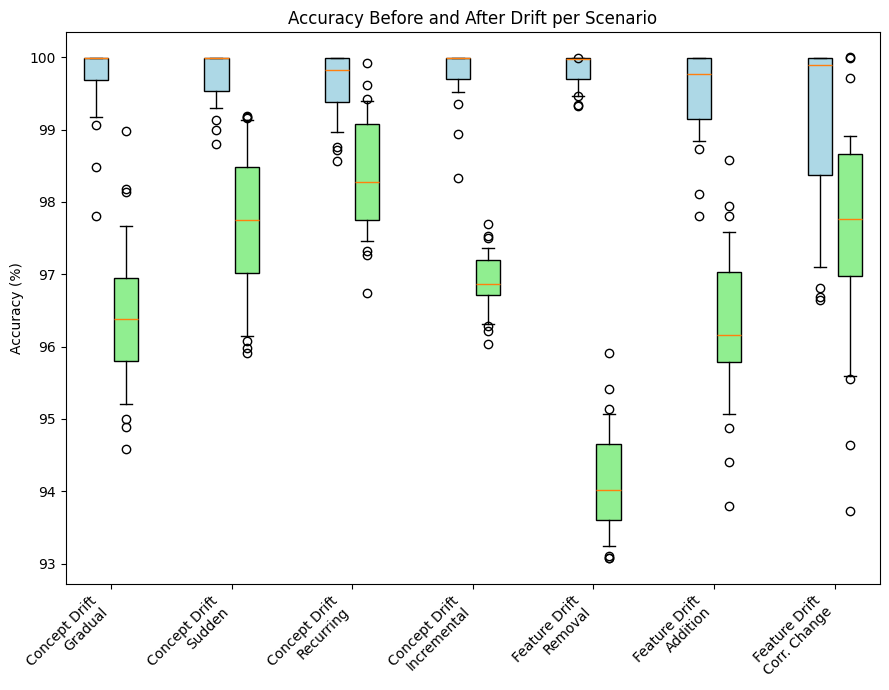

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data from the table ---
drift_types = [
    "Concept Drift", "Concept Drift", "Concept Drift", "Concept Drift",
    "Feature Drift", "Feature Drift", "Feature Drift"
]
drift_scenarios = [
    "Gradual", "Sudden", "Recurring", "Incremental",
    "Removal", "Addition", "Corr. Change"
]
accuracies_before = [99.98, 99.98, 99.99, 99.99, 99.98, 99.98, 99.98]  # in %
accuracies_after  = [96.80, 97.25, 98.62, 97.00, 94.12, 96.55, 97.58]   # in %

# --- Generate synthetic distributions ---
# (We simulate 30 samples per box for demonstration purposes)
np.random.seed(0)
num_samples = 30
std_accuracy = 0.25  # small std to simulate minor variation

all_data = []     # synthetic data for each boxplot
group_labels = [] # labels for each scenario group (drift type and scenario)
box_positions = []# positions for each of the 14 boxplots
box_colors = []   # colors: one for "Before" and one for "After"

# Use positions that are closer together:
# For each scenario, "Before" at pos = i*2 + 1, "After" at pos = i*2 + 1.5
for i in range(len(drift_types)):
    pos_before = i * 2 + 1
    pos_after  = i * 2 + 1.5
    box_positions.extend([pos_before, pos_after])
    
    # Synthetic data for "Before" and "After" accuracies
    data_before = np.random.normal(loc=accuracies_before[i], scale=np.random.uniform(0.3,1.5), size=num_samples)
    data_after  = np.random.normal(loc=accuracies_after[i], scale=np.random.uniform(0.3,1.5), size=num_samples)

    # if anym value is > 1, set it to 0.99
    data_before[data_before > 100] = 99.99
    data_after[data_after > 100] = 99.99
    all_data.append(data_before)
    all_data.append(data_after)
    
    # Label only with drift type and scenario
    label = f"{drift_types[i]}\n{drift_scenarios[i]}"
    group_labels.append(label)
    
    # Define colors: lightblue for "Before", lightgreen for "After"
    box_colors.extend(["lightblue", "lightgreen"])

# --- Create the figure and boxplots ---
fig, ax = plt.subplots(figsize=(9, 7))  # shorter height for better whisker visibility

# Set whiskers to the 10th and 90th percentiles
bp = ax.boxplot(all_data, positions=box_positions, widths=0.4, whis=[10, 90], patch_artist=True)

# Color each box
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)

# Set x-axis ticks at the center of each group
# Center position = (i*2 + 1 + i*2 + 1.5) / 2 = i*2 + 1.25
group_positions = [i * 2 + 1.25 for i in range(len(drift_types))]
ax.set_xticks(group_positions)
ax.set_xticklabels(group_labels, fontsize=10, rotation=45, ha="right")

ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy Before and After Drift per Scenario")

plt.tight_layout()
plt.savefig('boxplot_drift.png', dpi=500)
